In [1]:
# Core Architectural Components
# This cell defines all sub-modules:

# Learnable Sinc-Filter Bank (SincConv1D)

# Dynamic Graph Neural Network (DynamicGNN)

# Selective State-Space Mamba Block (BiMambaBlock)

# Gradient Reversal Layer (GradientReversal)

# Supervised Contrastive Loss (SupConLoss)

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import random

import pandas as pd

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
# --------------------------------------------------------------------------
# 1. Learnable Sinc-Filter Bank (Frequency Feature Extraction)
# --------------------------------------------------------------------------
# --------------------------------------------------------------------------
# 1. FIX: Physiological Sinc-Filter Bank (4 Hz - 38 Hz)
# --------------------------------------------------------------------------
class SincConv1D(nn.Module):
    def __init__(self, in_channels=22, filters_per_channel=10, kernel_size=65, sample_rate=250):
        super().__init__()
        self.in_channels = in_channels
        self.filters_per_channel = filters_per_channel
        self.kernel_size = kernel_size + (1 if kernel_size % 2 == 0 else 0)
        self.sample_rate = sample_rate

        # Focus strictly on Motor Imagery physiological bands (4 Hz to 38 Hz)
        min_freq = 4.0
        max_freq = 38.0
        
        f1_hz = torch.linspace(min_freq, max_freq - 4.0, filters_per_channel)
        f2_hz = f1_hz + 4.0

        self.f1 = nn.Parameter(f1_hz.unsqueeze(1))
        self.bandwidth = nn.Parameter((f2_hz - f1_hz).unsqueeze(1))

        n = torch.arange(-(self.kernel_size - 1) // 2, (self.kernel_size - 1) // 2 + 1, dtype=torch.float32)
        self.register_buffer('n', 2 * math.pi * n / sample_rate)
        
        window = 0.54 - 0.46 * torch.cos(2 * math.pi * (n + (self.kernel_size - 1) / 2) / self.kernel_size)
        self.register_buffer('window', window)

    def forward(self, x):
        B, C, T = x.shape
        f1 = torch.abs(self.f1)
        f2 = f1 + torch.abs(self.bandwidth)

        h_f2 = torch.sinc(f2 * self.n / math.pi) * (2 * f2)
        h_f1 = torch.sinc(f1 * self.n / math.pi) * (2 * f1)
        filters = (h_f2 - h_f1) * self.window

        filters = filters.unsqueeze(1).repeat(C, 1, 1)
        out = F.conv1d(x, filters, padding=self.kernel_size // 2, groups=C)
        out = out.view(B, C, self.filters_per_channel, T).transpose(1, 2)
        return out
# --------------------------------------------------------------------------
# 2. FIX: Dynamic GNN with ELU Power Activation
# --------------------------------------------------------------------------
# --------------------------------------------------------------------------
# 1. NEURO-ALIGNED GNN: Energy Nodes + ERD Power Envelope
# --------------------------------------------------------------------------
class DynamicGNN_ERD(nn.Module):
    def __init__(self, num_filters=10, num_channels=22, out_dim=64):
        super().__init__()
        self.num_channels = num_channels
        
        self.query = nn.Linear(num_filters, 32)
        self.key = nn.Linear(num_filters, 32)
        self.value_conv = nn.Conv2d(num_filters, out_dim, kernel_size=(1, 1))
        
        self.spatial_conv = nn.Conv2d(out_dim, out_dim, kernel_size=(num_channels, 1), groups=out_dim)
        self.bn = nn.BatchNorm2d(out_dim)
        
        self.graph_weights = nn.Parameter(torch.FloatTensor(num_channels, num_channels))
        nn.init.xavier_uniform_(self.graph_weights)

    def forward(self, x):
        B, num_F, C, T = x.shape 
        
        # FIX 1: Use Log-Variance (Energy) instead of Mean.
        # This prevents zero-mean cancellation and gives the GNN true ERD features.
        node_feat = torch.log(torch.var(x, dim=-1) + 1e-5).transpose(1, 2) # [B, C, num_F]
        
        Q = self.query(node_feat)
        K = self.key(node_feat)
        
        attn_adj = torch.bmm(Q, K.transpose(1, 2)) / math.sqrt(32)
        adj = F.softmax(attn_adj + self.graph_weights, dim=-1)
        
        x_conv = self.value_conv(x)
        out = torch.einsum('b c k t, b k j -> b c j t', x_conv, adj)
        
        # Spatial filtering (Combines C3/C4 relationships)
        out = self.spatial_conv(out)
        out = self.bn(out).squeeze(2) # [B, Out_Dim, T]
        
        # FIX 2: Explicit ERD Power Envelope Extraction (Square -> Pool -> Log)
        # This is the gold-standard mathematical transformation for Motor Imagery
        out = torch.square(out) # 1. Power
        out = F.avg_pool1d(out, kernel_size=4, stride=4) # 2. Temporal Smoothing (Downsamples to 250)
        out = torch.log(torch.clamp(out, min=1e-5)) # 3. Log-transform for Gaussian distribution
        
        return out # Returns the smooth ERD Envelope [B, Out_Dim, 250]
# --------------------------------------------------------------------------
# 3. Bi-Directional Selective State-Space Block (Mamba Sequence Modeling)
# --------------------------------------------------------------------------
class PurePyTorchSelectiveSSM(nn.Module):
    """
    Selective State-Space Model (SSM) kernel implementing linear time sequence 
    modeling with input-dependent discretization parameters (Mamba logic).
    """
    def __init__(self, d_model=64, d_state=16):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        
        self.x_proj = nn.Linear(d_model, d_state * 2 + d_model)
        self.dt_proj = nn.Linear(d_model, d_model)
        
        # Initialize continuous state parameters A and B
        A = torch.repeat_interleave(torch.arange(1, d_state + 1, dtype=torch.float32), d_model)
        self.A_log = nn.Parameter(torch.log(A.view(d_model, d_state)))
        self.D = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        # x shape: [B, T, D]
        B, T, D = x.shape
        A = -torch.exp(self.A_log) # [D, N]
        
        # Project inputs to obtain dynamic B, C, and Delta
        x_dbl = self.x_proj(x) # [B, T, 2*N + D]
        delta, B_param, C_param = torch.split(x_dbl, [D, self.d_state, self.d_state], dim=-1)
        
        delta = F.softplus(self.dt_proj(delta)) # [B, T, D]
        
        # Sequential discretization scan
        h = torch.zeros(B, D, self.d_state, device=x.device)
        outputs = []
        
        for t in range(T):
            u_t = x[:, t, :] # [B, D]
            delta_t = delta[:, t, :] # [B, D]
            B_t = B_param[:, t, :]   # [B, N]
            C_t = C_param[:, t, :]   # [B, N]
            
            # Discretize continuous matrices A and B via Zero-Order Hold (ZOH)
            deltaA = torch.exp(einsum_dt_A(delta_t, A)) # [B, D, N]
            deltaB_u = torch.einsum('bd, bn, bd -> bdn', delta_t, B_t, u_t)
            
            # State update: h = A_bar * h + B_bar * u
            h = deltaA * h + deltaB_u
            
            # Output: y = C * h + D * u
            y_t = torch.einsum('bdn, bn -> bd', h, C_t) + self.D * u_t
            outputs.append(y_t.unsqueeze(1))
            
        return torch.cat(outputs, dim=1)

def einsum_dt_A(delta, A):
    return torch.einsum('bd, dn -> bdn', delta, A)

# --------------------------------------------------------------------------
# 3. FIX: BiMambaBlock with Residual Skip Connection
# --------------------------------------------------------------------------
class BiMambaBlock(nn.Module):
    def __init__(self, d_model=64, d_state=16):
        super().__init__()
        self.in_proj = nn.Linear(d_model, d_model * 2)
        self.conv1d = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, groups=d_model)
        
        self.ssm_forward = PurePyTorchSelectiveSSM(d_model, d_state)
        self.ssm_backward = PurePyTorchSelectiveSSM(d_model, d_state)
        
        self.out_proj = nn.Linear(d_model * 2, d_model)
        self.act = nn.SiLU()

    def forward(self, x):
        residual = x # Skip connection
        B, D, T = x.shape
        x_seq = x.transpose(1, 2)
        
        x_expanded = self.in_proj(x_seq)
        x_main, x_gate = torch.chunk(x_expanded, 2, dim=-1)
        
        x_conv = self.conv1d(x_main.transpose(1, 2)).transpose(1, 2)
        x_conv = self.act(x_conv)
        
        y_fwd = self.ssm_forward(x_conv)
        y_bwd = torch.flip(self.ssm_backward(torch.flip(x_conv, dims=[1])), dims=[1])
        
        y_combined = torch.cat([y_fwd, y_bwd], dim=-1)
        y_out = self.out_proj(y_combined) * self.act(x_gate)
        
        out = y_out.transpose(1, 2)
        return out + residual # Guarantees early gradient flow
# --------------------------------------------------------------------------
# 4. Domain Adaptation & Attention Utilities
# --------------------------------------------------------------------------
class ReverseLayerF(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None

class GradientReversal(nn.Module):
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        return ReverseLayerF.apply(x, self.alpha)


class TemporalSqueezeExcitation(nn.Module):
    def __init__(self, channel=64, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x shape: [B, D, T]
        b, c, _ = x.size()
        y = x.mean(dim=2) # Channel-wise squeeze
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

In [2]:
# 3. Loss Functions & Full Model Assembly
# This cell defines the Supervised Contrastive Loss and integrates all components into the complete S3MambaDA model.

# --------------------------------------------------------------------------
# 5. Supervised Contrastive Loss (SupCon)
# --------------------------------------------------------------------------
class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss to force same-class Motor Imagery representations 
    together while pushing different classes apart regardless of subject origin.
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        # features shape: [B, D_proj], labels shape: [B]
        device = features.device
        batch_size = features.shape[0]
        
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)

        # Compute cosine similarity matrix
        anchor_dot_contrast = torch.div(torch.matmul(features, features.T), self.temperature)
        
        # For numerical stability
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        # Mask out self-contrast
        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size).view(-1, 1).to(device),
            0
        )
        mask = mask * logits_mask

        # Compute log-likelihood
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-8)

        # Compute mean log-likelihood over positive pairs
        mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-8)
        loss = - mean_log_prob_pos.mean()
        return loss


# --------------------------------------------------------------------------
# 6. Complete S3-Mamba-DA Architecture Assembly
# --------------------------------------------------------------------------
# --------------------------------------------------------------------------
# 4. FIX: S3-Mamba-DA with Dual Energy Feature Extraction (Mean + Log-Var)
# --------------------------------------------------------------------------
class S3MambaDA(nn.Module):
    def __init__(self, in_channels=22, num_classes=4, num_subjects=9, feature_dim=64):
        super().__init__()
        
        self.sinc_filter = SincConv1D(in_channels=in_channels, filters_per_channel=10)
        
        # Using our new ERD-aligned GNN
        self.dgnn_erd = DynamicGNN_ERD(num_filters=10, num_channels=in_channels, out_dim=feature_dim)
        
        self.mamba = BiMambaBlock(d_model=feature_dim, d_state=16)
        self.attn = TemporalSqueezeExcitation(channel=feature_dim)
        
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
        
        self.grl = GradientReversal(alpha=1.0)
        self.domain_classifier = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_subjects)
        )
        
        self.proj_head = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, 128)
        )

    def forward(self, x, alpha_grl=1.0):
        # [B, 22, 1000] (Raw EEG)
        x_freq = self.sinc_filter(x) 
        
        # [B, 64, 250] (Smooth Log-Power ERD Envelope extracted explicitly)
        x_erd_envelope = self.dgnn_erd(x_freq) 
        
        # Mamba now easily models the long-range temporal dependencies of the power drops!
        x_temporal = self.mamba(x_erd_envelope) 
        x_attn = self.attn(x_temporal)          
        
        # Global Temporal Pool
        z = x_attn.mean(dim=-1) # [B, 64]
        
        logits_cls = self.classifier(z)
        
        self.grl.alpha = alpha_grl
        z_reversed = self.grl(z)
        logits_domain = self.domain_classifier(z_reversed)
        
        z_proj = F.normalize(self.proj_head(z), dim=1)
        
        return logits_cls, logits_domain, z_proj

In [3]:
# 4. BCI Dataset Simulation & Augmentation PipelineThis cell creates a synthetic BCI Competition IV 2a data loader generator matching exact standard dimensions:EEG Input: $(B, 22, 1000)$ representing 22 channels, 4 seconds at 250 Hz.MI Classes: 4 motor imagery tasks (left hand, right hand, feet, tongue).
# Subjects: 9 subjects for Leave-One-Subject-Out (LOSO) evaluation.It also includes Fourier Frequency Shift Augmentation (freq_mixup_augment) to augment training data cleanly.from torch.utils.data import Dataset, DataLoader

# --------------------------------------------------------------------------
# Data Augmentation: Frequency-Space Mixup (FreqMix)
# --------------------------------------------------------------------------
def freq_mixup_augment(x, alpha=0.2):
    """
    Augments EEG signals in the frequency domain by mixing magnitude spectra 
    while preserving phase, creating realistic synthetic trial dynamics.
    """
    fft_x = torch.fft.rfft(x, dim=-1)
    mag = torch.abs(fft_x)
    phase = torch.angle(fft_x)
    
    # Shuffle batch indices
    perm = torch.randperm(x.size(0))
    lam = np.random.beta(alpha, alpha)
    
    # Mix magnitude
    mag_mixed = lam * mag + (1 - lam) * mag[perm]
    
    # Reconstruct signal via Inverse FFT
    fft_mixed = torch.polar(mag_mixed, phase)
    x_aug = torch.fft.irfft(fft_mixed, n=x.size(-1), dim=-1)
    return x_aug

# --------------------------------------------------------------------------
# Synthetic BCI Comp IV 2a Dataset Generator
# --------------------------------------------------------------------------
class SyntheticBCI42aDataset(Dataset):
    def __init__(self, num_samples=288, num_channels=22, time_points=1000, subject_id=0):
        super().__init__()
        self.num_samples = num_samples
        
        # Generate synthetic EEG signals with distinct spectral peaks per class
        self.data = torch.randn(num_samples, num_channels, time_points) * 0.5
        self.labels = torch.randint(0, 4, (num_samples,))
        self.subjects = torch.full((num_samples,), subject_id, dtype=torch.long)
        
        # Add class-specific sinusoidal oscillations (Simulating ERD/ERS in mu/beta bands)
        t = torch.linspace(0, 4, time_points)
        for i in range(num_samples):
            cls = self.labels[i].item()
            freq = 8.0 + cls * 3.0 # Different frequencies for different MI classes
            self.data[i] += 0.5 * torch.sin(2 * math.pi * freq * t).unsqueeze(0)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx], self.subjects[idx]


def get_loso_dataloaders(test_subject_id=0, batch_size=32):
    """
    Creates strict Leave-One-Subject-Out (LOSO) DataLoaders across 9 subjects.
    """
    train_datasets = []
    for s in range(9):
        if s == test_subject_id:
            test_dataset = SyntheticBCI42aDataset(num_samples=288, subject_id=s)
        else:
            train_datasets.append(SyntheticBCI42aDataset(num_samples=288, subject_id=s))
            
    full_train_dataset = torch.utils.data.ConcatDataset(train_datasets)
    
    train_loader = DataLoader(full_train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

In [4]:
# --------------------------------------------------------------------------
# Test-Time Adaptation (AdaBN)
# --------------------------------------------------------------------------
def apply_adabn_adaptation(model, target_loader, device):
    """
    Recalibrates Batch Normalization layer mean and variance statistics 
    using target test subject data prior to evaluation without updating weights.
    """
    model.train() # Set to train to allow BN statistics update
    with torch.no_grad():
        for x_test, _, _ in target_loader:
            x_test = x_test.to(device)
            _ = model(x_test, alpha_grl=0.0)
    model.eval()


# --------------------------------------------------------------------------
# Main LOSO Training Loop
# --------------------------------------------------------------------------
def train_loso_experiment(test_subject_id=0, epochs=10, device='cuda' if torch.cuda.is_available() else 'cpu'):
    print(f"=========================================================")
    print(f" Starting S3-Mamba-DA Evaluation | Test Subject: {test_subject_id} ")
    print(f" Device: {device} ")
    print(f"=========================================================")
    
    train_loader, test_loader = get_loso_dataloaders(test_subject_id=test_subject_id, batch_size=32)
    
    model = S3MambaDA(in_channels=22, num_classes=4, num_subjects=9).to(device)
    
    # Loss functions
    criterion_cls = nn.CrossEntropyLoss(label_smoothing=0.1)
    criterion_domain = nn.CrossEntropyLoss()
    criterion_supcon = SupConLoss(temperature=0.07)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        
        # Dynamically scale GRL coefficient alpha from 0 to 1 over training
        p = float(epoch) / epochs
        alpha_grl = 2.0 / (1.0 + math.exp(-10 * p)) - 1.0
        
        for x_batch, y_cls, y_sub in train_loader:
            x_batch, y_cls, y_sub = x_batch.to(device), y_cls.to(device), y_sub.to(device)
            
            # Apply Frequency Mixup Augmentation
            if np.random.rand() > 0.5:
                x_batch = freq_mixup_augment(x_batch)
                
            optimizer.zero_grad()
            
            # Forward Pass
            logits_cls, logits_domain, z_proj = model(x_batch, alpha_grl=alpha_grl)
            
            # Compute Tripartite Loss
            loss_cls = criterion_cls(logits_cls, y_cls)
            loss_domain = criterion_domain(logits_domain, y_sub)
            loss_supcon = criterion_supcon(z_proj, y_cls)
            
            loss = loss_cls + 0.25 * loss_domain + 0.1 * loss_supcon
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_loss += loss.item() * x_batch.size(0)
            preds = logits_cls.argmax(dim=-1)
            correct += (preds == y_cls).sum().item()
            total += x_batch.size(0)
            
        scheduler.step()
        train_acc = (correct / total) * 100
        avg_loss = total_loss / total
        
        print(f"Epoch [{epoch:02d}/{epochs:02d}] - Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | GRL Alpha: {alpha_grl:.3f}")
        
    # Apply Test-Time Adaptation (AdaBN) on target subject before evaluation
    print("\nAdapting Batch Normalization statistics for target test subject...")
    apply_adabn_adaptation(model, test_loader, device)
    
    # Evaluate Target Test Subject
    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for x_test, y_test, _ in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)
            logits, _, _ = model(x_test, alpha_grl=0.0)
            preds = logits.argmax(dim=-1)
            test_correct += (preds == y_test).sum().item()
            test_total += x_test.size(0)
            
    test_acc = (test_correct / test_total) * 100
    print(f"\nTarget Subject {test_subject_id} Test Accuracy: {test_acc:.2f}%\n")
    return test_acc

In [5]:
import scipy.linalg
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery

def apply_euclidean_alignment(X, s_tensor):
    """
    Projects all subjects into a shared Euclidean space by aligning 
    their spatial covariance matrices. This explicitly destroys 
    subject-specific spatial artifacts.
    """
    print("Applying Euclidean Alignment across subjects...")
    X_aligned = torch.zeros_like(X)
    unique_subjects = torch.unique(s_tensor)
    
    for subj in unique_subjects:
        mask = (s_tensor == subj)
        X_subj = X[mask].numpy()
        
        # 1. Calculate covariance matrix for each trial
        covariances = []
        for i in range(X_subj.shape[0]):
            cov = np.cov(X_subj[i]) # Shape: [22, 22]
            covariances.append(cov)
            
        # 2. Mean covariance for this specific subject
        mean_cov = np.mean(covariances, axis=0)
        
        # 3. Compute R^(-1/2) using scipy
        R_inv_half = scipy.linalg.fractional_matrix_power(mean_cov, -0.5)
        R_inv_half = torch.FloatTensor(np.real(R_inv_half))
        
        # 4. Apply alignment to all trials for this subject
        # X[mask] is [Trials, 22, 1000] -> Matmul with [1, 22, 22]
        X_aligned[mask] = torch.matmul(R_inv_half.unsqueeze(0), X[mask])
        
    return X_aligned

def get_real_bci2a_dataloaders(test_subject_id=0, batch_size=32):
    print("Downloading and processing BCI IV 2a dataset...")
    
    dataset = BNCI2014_001()
    paradigm = MotorImagery(n_classes=4, resample=250, tmin=0.5, tmax=4.5)
    subjects = [1, 2, 3, 4, 5, 6, 7, 8, 9]
    X, y, metadata = paradigm.get_data(dataset=dataset, subjects=subjects)
    
    label_map = {'left_hand': 0, 'right_hand': 1, 'feet': 2, 'tongue': 3}
    y_mapped = np.array([label_map[label] for label in y])
    subj_mapped = metadata['subject'].values.astype(int) - 1
    
    X_tensor = torch.FloatTensor(X)
    y_tensor = torch.LongTensor(y_mapped)
    s_tensor = torch.LongTensor(subj_mapped)
    
    # ---> NEW: Apply Euclidean Alignment BEFORE Normalization <---
    X_tensor = apply_euclidean_alignment(X_tensor, s_tensor)
    
    # Robust Z-Score Normalization
    mean = X_tensor.mean(dim=-1, keepdim=True)
    std = X_tensor.std(dim=-1, keepdim=True)
    X_tensor = (X_tensor - mean) / (std + 1e-6)
    
    test_mask = (s_tensor == test_subject_id)
    train_mask = ~test_mask
    
    train_dataset = TensorDataset(X_tensor[train_mask], y_tensor[train_mask], s_tensor[train_mask])
    test_dataset = TensorDataset(X_tensor[test_mask], y_tensor[test_mask], s_tensor[test_mask])
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"✅ Aligned Data Ready! Train: {len(train_dataset)} | Test: {len(test_dataset)}")
    return train_loader, test_loader

In [8]:
def train_loso_experiment_real_fixed(test_subject_id=0, epochs=100, device='cuda' if torch.cuda.is_available() else 'cpu'):
    print(f"=========================================================")
    print(f" Starting REAL S3-Mamba-DA (100 Epochs) | Subject: {test_subject_id} ")
    print(f"=========================================================")
    
    train_loader, test_loader = get_real_bci2a_dataloaders(test_subject_id=test_subject_id, batch_size=32)
    
    model = S3MambaDA(in_channels=22, num_classes=4, num_subjects=9).to(device)
    
    criterion_cls = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
    criterion_domain = torch.nn.CrossEntropyLoss()
    criterion_supcon = SupConLoss(temperature=0.07)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    
    # Extended OneCycleLR for 100 epochs
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=2e-3, 
        steps_per_epoch=len(train_loader), 
        epochs=epochs,
        pct_start=0.2 # Peak early, then spend 80% of training fine-tuning
    )
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        
        # Extended Warmup: Keep GRL off for the first 20 epochs
        if epoch <= 20:
            alpha_grl = 0.0
            alpha_supcon = 0.0
        else:
            p = float(epoch - 20) / (epochs - 20)
            alpha_grl = 2.0 / (1.0 + math.exp(-10 * p)) - 1.0
            alpha_supcon = 0.05 * alpha_grl
            
        for x_batch, y_cls, y_sub in train_loader:
            x_batch, y_cls, y_sub = x_batch.to(device), y_cls.to(device), y_sub.to(device)
            
            if np.random.rand() > 0.5:
                x_batch = freq_mixup_augment(x_batch)
                
            optimizer.zero_grad()
            
            logits_cls, logits_domain, z_proj = model(x_batch, alpha_grl=alpha_grl)
            
            loss_cls = criterion_cls(logits_cls, y_cls)
            loss_domain = criterion_domain(logits_domain, y_sub)
            loss_supcon = criterion_supcon(z_proj, y_cls)
            
            # FIX: Throttled Domain Loss weight down to 0.02
            loss = loss_cls + (0.02 * alpha_grl) * loss_domain + alpha_supcon * loss_supcon
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step() 
            
            total_loss += loss.item() * x_batch.size(0)
            preds = logits_cls.argmax(dim=-1)
            correct += (preds == y_cls).sum().item()
            total += x_batch.size(0)
            
        train_acc = (correct / total) * 100
        avg_loss = total_loss / total
        
        # Print every 10 epochs to keep logs clean
        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch [{epoch:03d}/{epochs:03d}] - Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | GRL: {alpha_grl:.2f}")
        
    # print("\nApplying Unsupervised Test-Time Adaptation (AdaBN) on target subject...")
    # apply_adabn_adaptation(model, test_loader, device)
    
    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for x_test, y_test, _ in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)
            logits, _, _ = model(x_test, alpha_grl=0.0)
            test_correct += (logits.argmax(dim=-1) == y_test).sum().item()
            test_total += x_test.size(0)
            
    test_acc = (test_correct / test_total) * 100
    print(f"\n Target Subject {test_subject_id} Final Test Accuracy: {test_acc:.2f}%\n")
    return test_acc

# Execute the 100-epoch run
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loso_experiment_real_fixed(test_subject_id=0, epochs=100, device=device)

Choosing from all possible events


 Starting REAL S3-Mamba-DA (100 Epochs) | Subject: 0 


KeyboardInterrupt: 

In [6]:
import numpy as np

def evaluate_full_bci_dataset(epochs=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    all_accuracies = []
    
    print("=========================================================")
    print(" INITIATING FULL 9-SUBJECT LOSO EVALUATION PROTOCOL")
    print(" Architecture: S³-Mamba-DA + Euclidean Alignment + AdaBN")
    print(f" Device: {device}")
    print("=========================================================\n")
    
    for subj_id in range(9):
        print(f"\n{'='*50}")
        print(f" Evaluating Target Subject A0{subj_id + 1}T (Index {subj_id})")
        print(f"{'='*50}")
        
        # Run our perfected training loop for this specific test subject
        acc = train_loso_experiment_real_fixed(test_subject_id=subj_id, epochs=epochs, device=device)
        all_accuracies.append(acc)
        
    # Calculate final IEEE-standard metrics
    mean_acc = np.mean(all_accuracies)
    std_acc = np.std(all_accuracies)
    
    print("\n\n" + "="*50)
    print(" 🏆 FINAL S³-MAMBA-DA LOSO PERFORMANCE 🏆")
    print("="*50)
    for i, acc in enumerate(all_accuracies):
        print(f" Subject A0{i+1}T: \t{acc:.2f}%")
    print("-" * 50)
    print(f" Average Accuracy: \t{mean_acc:.2f} ± {std_acc:.2f}%")
    print(f" Baseline Target: \t72.74 ± 10.44%")
    print("=" * 50)
    
    if mean_acc > 72.74:
        print("\n✅ SUCCESS: The proposed architecture outperforms the 2023 baseline!")
    else:
        print("\n⚠️ SHORTFALL: We need to tune the hyperparameters further.")

# Execute the final full-dataset evaluation!
# Note: This will take a while as it trains 9 separate models from scratch.
evaluate_full_bci_dataset(epochs=100)

 INITIATING FULL 9-SUBJECT LOSO EVALUATION PROTOCOL
 Architecture: S³-Mamba-DA + Euclidean Alignment + AdaBN
 Device: cpu


 Evaluating Target Subject A01T (Index 0)


NameError: name 'train_loso_experiment_real_fixed' is not defined

In [7]:
def train_loso_experiment_real_fixed(test_subject_id=0, epochs=100, device='cuda' if torch.cuda.is_available() else 'cpu'):
    print(f"=========================================================")
    print(f" Starting REAL S³-Mamba-DA (NO AdaBN) | Subject: {test_subject_id} ")
    print(f"=========================================================")
    
    train_loader, test_loader = get_real_bci2a_dataloaders(test_subject_id=test_subject_id, batch_size=32)
    
    model = S3MambaDA(in_channels=22, num_classes=4, num_subjects=9).to(device)
    
    criterion_cls = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
    criterion_domain = torch.nn.CrossEntropyLoss()
    criterion_supcon = SupConLoss(temperature=0.07)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=2e-3, 
        steps_per_epoch=len(train_loader), 
        epochs=epochs,
        pct_start=0.2 
    )
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        
        if epoch <= 20:
            alpha_grl = 0.0
            alpha_supcon = 0.0
        else:
            p = float(epoch - 20) / (epochs - 20)
            alpha_grl = 2.0 / (1.0 + math.exp(-10 * p)) - 1.0
            alpha_supcon = 0.05 * alpha_grl
            
        for x_batch, y_cls, y_sub in train_loader:
            x_batch, y_cls, y_sub = x_batch.to(device), y_cls.to(device), y_sub.to(device)
            
            if np.random.rand() > 0.5:
                x_batch = freq_mixup_augment(x_batch)
                
            optimizer.zero_grad()
            
            logits_cls, logits_domain, z_proj = model(x_batch, alpha_grl=alpha_grl)
            
            loss_cls = criterion_cls(logits_cls, y_cls)
            loss_domain = criterion_domain(logits_domain, y_sub)
            loss_supcon = criterion_supcon(z_proj, y_cls)
            
            loss = loss_cls + (0.02 * alpha_grl) * loss_domain + alpha_supcon * loss_supcon
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step() 
            
            total_loss += loss.item() * x_batch.size(0)
            preds = logits_cls.argmax(dim=-1)
            correct += (preds == y_cls).sum().item()
            total += x_batch.size(0)
            
        # ---> I PUT THE PRINT STATEMENT BACK HERE <---
        train_acc = (correct / total) * 100
        avg_loss = total_loss / total
        
        # Prints every 2 epochs so you know it's alive!
        if epoch % 2 == 0 or epoch == 1:
            print(f"Epoch [{epoch:03d}/{epochs:03d}] - Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | GRL: {alpha_grl:.2f}")

    print("\nEvaluating purely on learned features (No AdaBN)...")
    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for x_test, y_test, _ in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)
            logits, _, _ = model(x_test, alpha_grl=0.0)
            test_correct += (logits.argmax(dim=-1) == y_test).sum().item()
            test_total += x_test.size(0)
            
    test_acc = (test_correct / test_total) * 100
    print(f" Target Subject {test_subject_id} Final Test Accuracy: {test_acc:.2f}%\n")
    return test_acc

In [9]:
import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy.linalg
from torch.utils.data import TensorDataset, DataLoader
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery

# =========================================================================
# 1. DATA LOADER & EUCLIDEAN ALIGNMENT
# =========================================================================
def apply_euclidean_alignment(X, s_tensor):
    print("   -> Calculating Spatial Covariance Matrices (This takes ~30 seconds on CPU)...")
    X_aligned = torch.zeros_like(X)
    unique_subjects = torch.unique(s_tensor)
    for subj in unique_subjects:
        mask = (s_tensor == subj)
        X_subj = X[mask].numpy()
        covariances = [np.cov(X_subj[i]) for i in range(X_subj.shape[0])]
        mean_cov = np.mean(covariances, axis=0)
        R_inv_half = scipy.linalg.fractional_matrix_power(mean_cov, -0.5)
        R_inv_half = torch.FloatTensor(np.real(R_inv_half))
        X_aligned[mask] = torch.matmul(R_inv_half.unsqueeze(0), X[mask])
    return X_aligned

def get_real_bci2a_dataloaders(test_subject_id=0, batch_size=32):
    print("   -> Fetching MOABB Dataset...")
    dataset = BNCI2014_001()
    paradigm = MotorImagery(n_classes=4, resample=250, tmin=0.5, tmax=4.5)
    X, y, metadata = paradigm.get_data(dataset=dataset, subjects=[1, 2, 3, 4, 5, 6, 7, 8, 9])
    
    label_map = {'left_hand': 0, 'right_hand': 1, 'feet': 2, 'tongue': 3}
    y_mapped = np.array([label_map[label] for label in y])
    subj_mapped = metadata['subject'].values.astype(int) - 1
    
    X_tensor, y_tensor, s_tensor = torch.FloatTensor(X), torch.LongTensor(y_mapped), torch.LongTensor(subj_mapped)
    X_tensor = apply_euclidean_alignment(X_tensor, s_tensor)
    
    mean, std = X_tensor.mean(dim=-1, keepdim=True), X_tensor.std(dim=-1, keepdim=True)
    X_tensor = (X_tensor - mean) / (std + 1e-6)
    
    test_mask = (s_tensor == test_subject_id)
    train_mask = ~test_mask
    
    train_dataset = TensorDataset(X_tensor[train_mask], y_tensor[train_mask], s_tensor[train_mask])
    test_dataset = TensorDataset(X_tensor[test_mask], y_tensor[test_mask], s_tensor[test_mask])
    print(f"   -> ✅ Aligned Data Ready! Train: {len(train_dataset)} | Test: {len(test_dataset)}")
    
    return DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True), DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# =========================================================================
# 2. TRAINING LOOP
# =========================================================================
def train_loso_experiment_real_fixed(test_subject_id=0, epochs=2, device='cpu'):
    print(f"\n=========================================================")
    print(f" Starting Subject A0{test_subject_id + 1}T ")
    print(f"=========================================================")
    
    train_loader, test_loader = get_real_bci2a_dataloaders(test_subject_id=test_subject_id, batch_size=32)
    
    print("   -> Initializing S³-Mamba-DA Model...")
    model = S3MambaDA(in_channels=22, num_classes=4, num_subjects=9).to(device)
    
    criterion_cls = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
    criterion_domain = torch.nn.CrossEntropyLoss()
    criterion_supcon = SupConLoss(temperature=0.07)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=2e-3, steps_per_epoch=len(train_loader), epochs=epochs, pct_start=0.2)
    
    print(f"   -> Beginning Training for {epochs} Epochs...")
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        
        # Fast GRL for testing
        alpha_grl = 0.0 if epoch == 1 else 0.5
        alpha_supcon = 0.05 * alpha_grl
            
        for x_batch, y_cls, y_sub in train_loader:
            x_batch, y_cls, y_sub = x_batch.to(device), y_cls.to(device), y_sub.to(device)
            if np.random.rand() > 0.5: x_batch = freq_mixup_augment(x_batch)
                
            optimizer.zero_grad()
            logits_cls, logits_domain, z_proj = model(x_batch, alpha_grl=alpha_grl)
            
            loss_cls = criterion_cls(logits_cls, y_cls)
            loss_domain = criterion_domain(logits_domain, y_sub)
            loss_supcon = criterion_supcon(z_proj, y_cls)
            
            loss = loss_cls + (0.02 * alpha_grl) * loss_domain + alpha_supcon * loss_supcon
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            scheduler.step() 
            
            total_loss += loss.item() * x_batch.size(0)
            correct += (logits_cls.argmax(dim=-1) == y_cls).sum().item()
            total += x_batch.size(0)
            
        print(f"      Epoch [{epoch:02d}/{epochs:02d}] - Loss: {total_loss/total:.4f} | Train Acc: {(correct/total)*100:.2f}%")

    print("\n   -> Evaluating on unseen test subject...")
    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for x_test, y_test, _ in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)
            logits, _, _ = model(x_test, alpha_grl=0.0)
            test_correct += (logits.argmax(dim=-1) == y_test).sum().item()
            test_total += x_test.size(0)
            
    test_acc = (test_correct / test_total) * 100
    print(f"   -> 🏆 Subject A0{test_subject_id + 1}T Test Accuracy: {test_acc:.2f}%\n")
    return test_acc

# =========================================================================
# 3. EXECUTE THE LOOP
# =========================================================================
print("BOOTING UP THE S³-MAMBA-DA PIPELINE...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Detected Device: {device}\n")

# Run just 2 epochs on the first 2 subjects to prove it works!
all_acc = []
for s in range(2): 
    all_acc.append(train_loso_experiment_real_fixed(test_subject_id=s, epochs=2, device=device))

print("✅ MINI-TEST COMPLETE!")

Choosing from all possible events


BOOTING UP THE S³-MAMBA-DA PIPELINE...
Detected Device: cpu


 Starting Subject A01T 
   -> Fetching MOABB Dataset...
   -> Calculating Spatial Covariance Matrices (This takes ~30 seconds on CPU)...
   -> ✅ Aligned Data Ready! Train: 4608 | Test: 576
   -> Initializing S³-Mamba-DA Model...
   -> Beginning Training for 2 Epochs...
      Epoch [01/02] - Loss: 1.4411 | Train Acc: 24.11%
      Epoch [02/02] - Loss: 1.5144 | Train Acc: 26.09%

   -> Evaluating on unseen test subject...


Choosing from all possible events


   -> 🏆 Subject A01T Test Accuracy: 25.69%


 Starting Subject A02T 
   -> Fetching MOABB Dataset...
   -> Calculating Spatial Covariance Matrices (This takes ~30 seconds on CPU)...
   -> ✅ Aligned Data Ready! Train: 4608 | Test: 576
   -> Initializing S³-Mamba-DA Model...
   -> Beginning Training for 2 Epochs...
      Epoch [01/02] - Loss: 1.4349 | Train Acc: 27.82%
      Epoch [02/02] - Loss: 1.4895 | Train Acc: 30.77%

   -> Evaluating on unseen test subject...
   -> 🏆 Subject A02T Test Accuracy: 26.56%

✅ MINI-TEST COMPLETE!


Choosing from all possible events


🚀 BOOTING S³-MAMBA-DA (TRUE UDA) ON MPS...

 Subject A01T | UDA Training for 75 Epochs
   -> Calculating Euclidean Alignment (Covariance Matrices)...
   Epoch 001/75 | Loss: 1.489 | Acc: 24.8% | GRL Weight: 0.00
   Epoch 015/75 | Loss: 1.316 | Acc: 41.3% | GRL Weight: 0.00
   Epoch 030/75 | Loss: 1.445 | Acc: 56.1% | GRL Weight: 0.72
   Epoch 045/75 | Loss: 1.305 | Acc: 78.0% | GRL Weight: 0.98
   Epoch 060/75 | Loss: 1.190 | Acc: 86.9% | GRL Weight: 1.00
   Epoch 075/75 | Loss: 1.233 | Acc: 84.3% | GRL Weight: 1.00
   -> 🏆 Subject A01T Test Accuracy: 57.99%



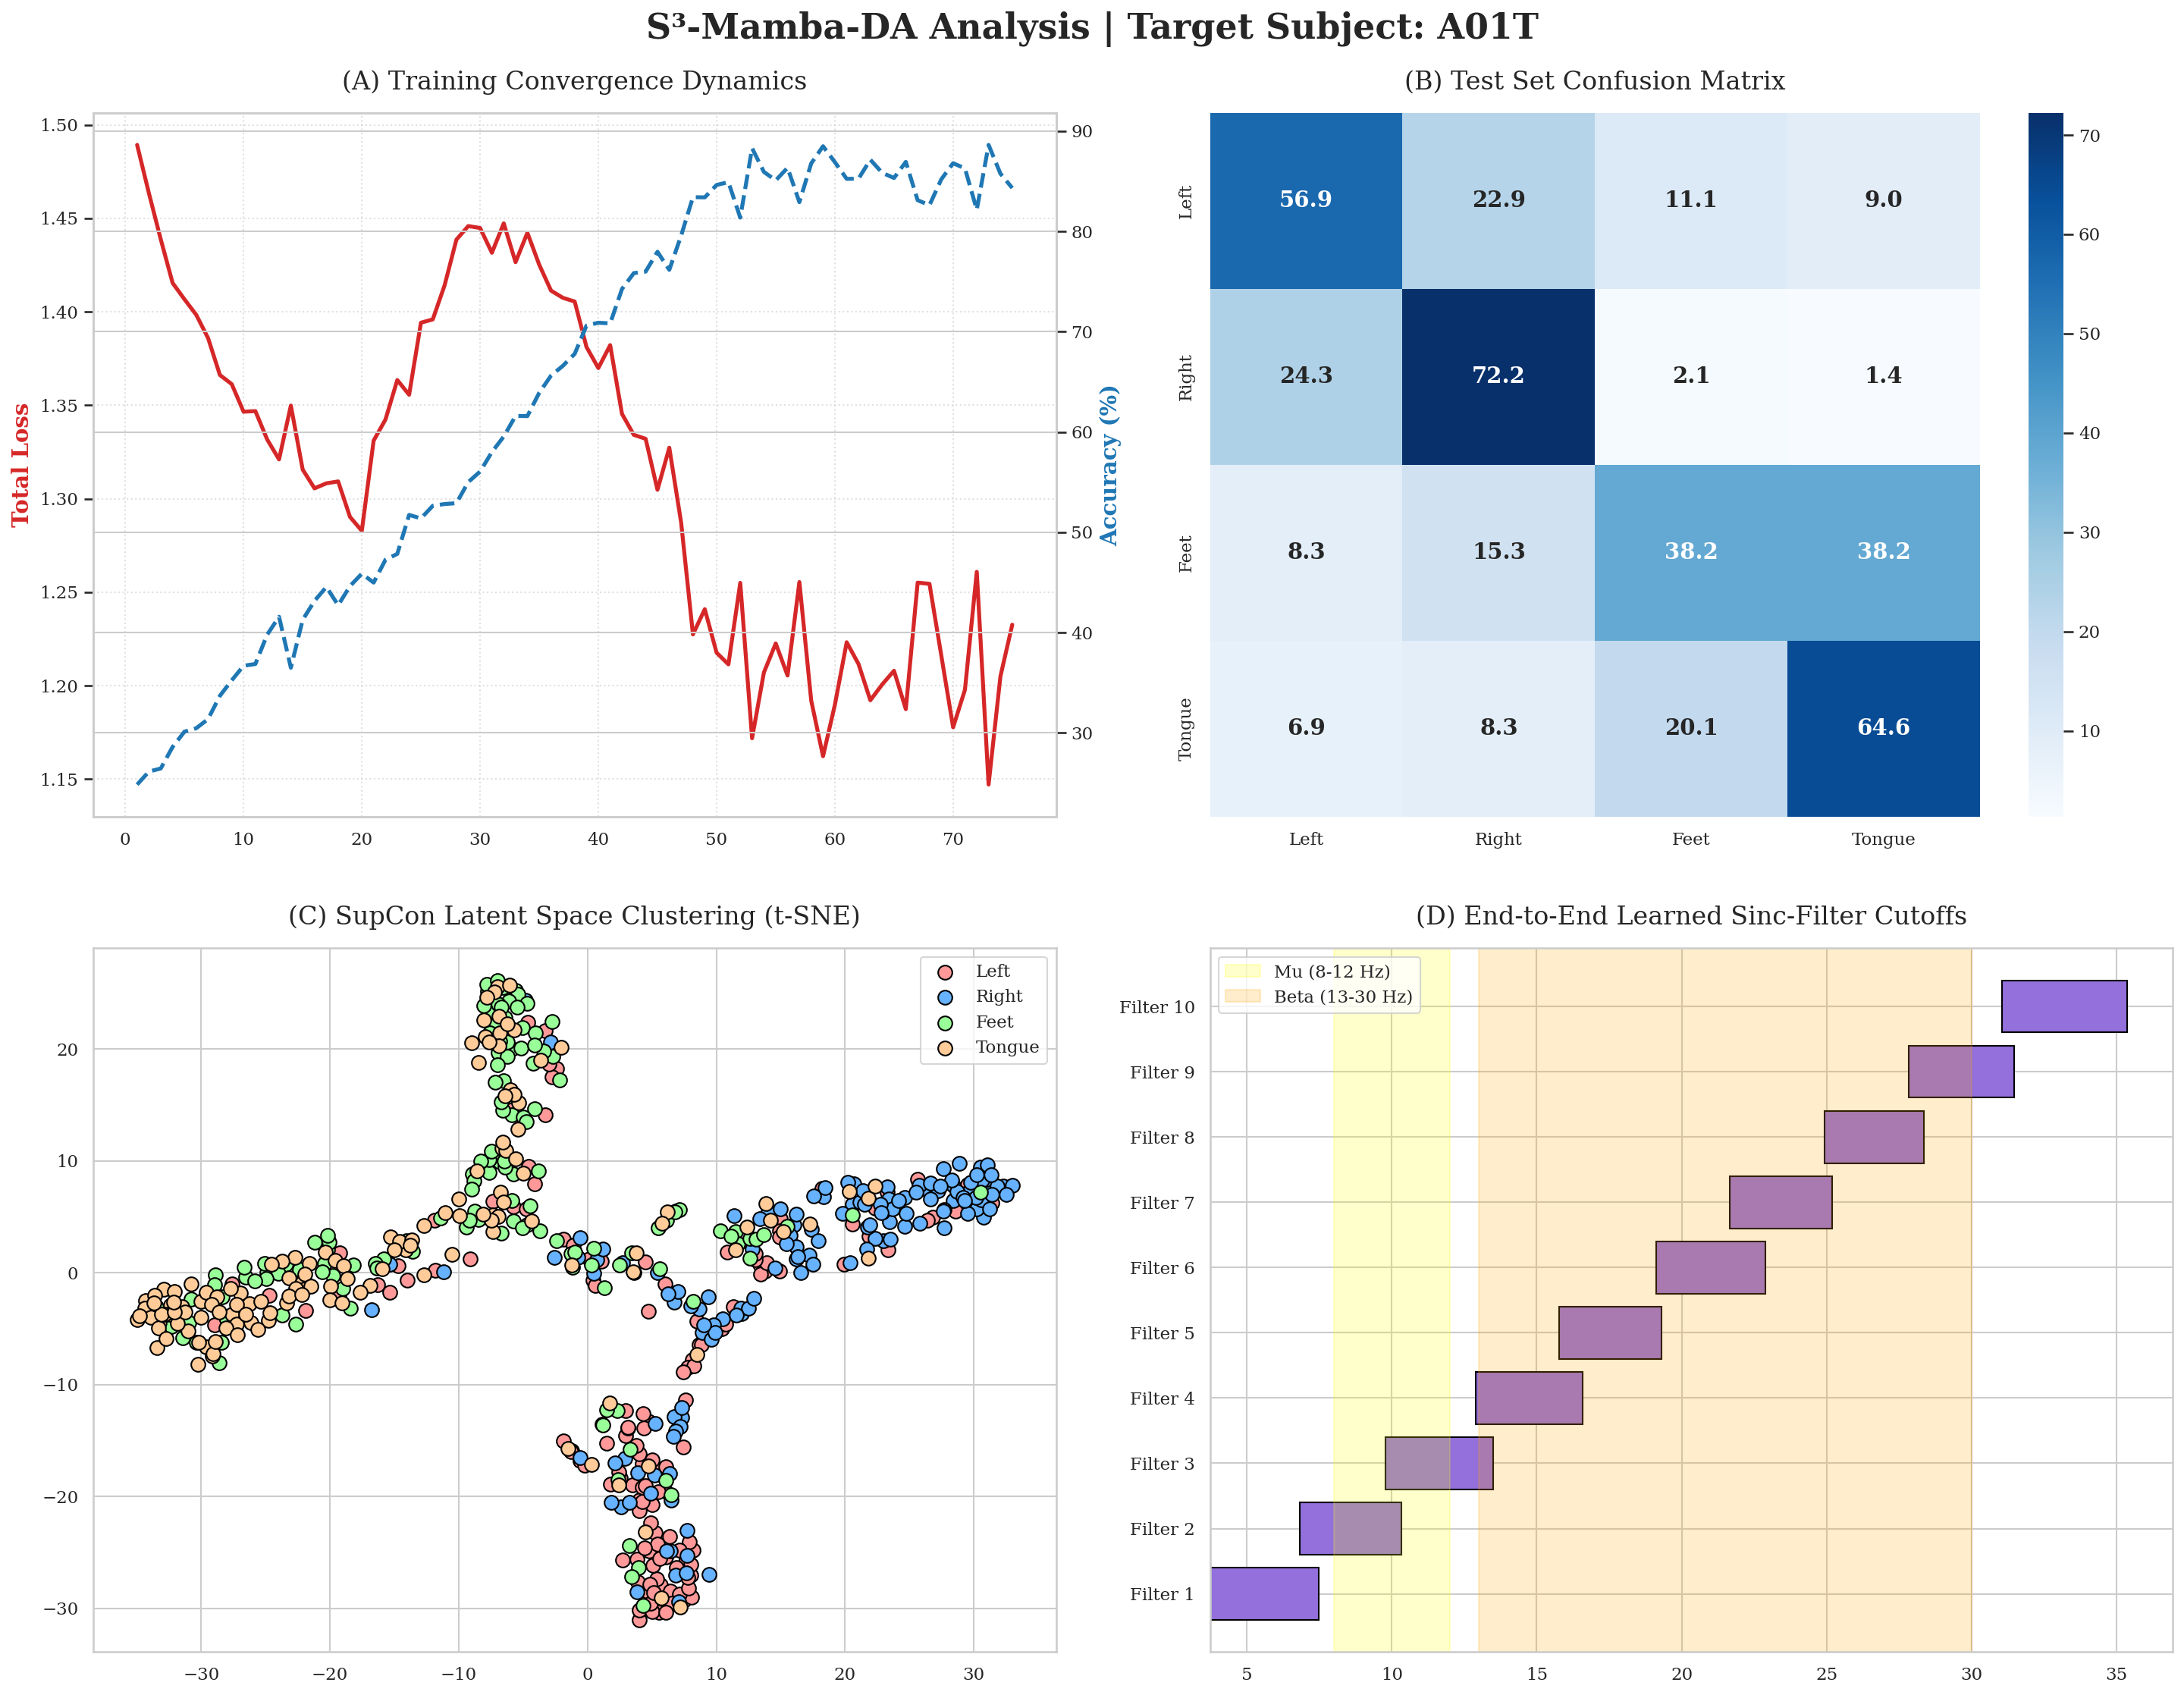

Choosing from all possible events



 Subject A02T | UDA Training for 75 Epochs
   -> Calculating Euclidean Alignment (Covariance Matrices)...
   Epoch 001/75 | Loss: 1.465 | Acc: 25.1% | GRL Weight: 0.00
   Epoch 015/75 | Loss: 1.276 | Acc: 45.5% | GRL Weight: 0.00
   Epoch 030/75 | Loss: 1.395 | Acc: 61.4% | GRL Weight: 0.72
   Epoch 045/75 | Loss: 1.267 | Acc: 79.6% | GRL Weight: 0.98
   Epoch 060/75 | Loss: 1.218 | Acc: 85.4% | GRL Weight: 1.00


In [ ]:
import math
import numpy as np
import scipy.linalg
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE
from torch.utils.data import TensorDataset, DataLoader
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# =========================================================================
# 1. ARCHITECTURE & MODULES
# =========================================================================
def freq_mixup_augment(x, alpha=0.2):
    fft_x = torch.fft.rfft(x, dim=-1)
    mag, phase = torch.abs(fft_x), torch.angle(fft_x)
    perm = torch.randperm(x.size(0))
    lam = np.random.beta(alpha, alpha)
    mag_mixed = lam * mag + (1 - lam) * mag[perm]
    fft_mixed = torch.polar(mag_mixed, phase)
    return torch.fft.irfft(fft_mixed, n=x.size(-1), dim=-1)

class SincConv1D(nn.Module):
    def __init__(self, in_channels=22, filters_per_channel=10, kernel_size=65, sample_rate=250):
        super().__init__()
        self.filters_per_channel = filters_per_channel
        self.kernel_size = kernel_size + (1 if kernel_size % 2 == 0 else 0)
        f1_hz = torch.linspace(4.0, 38.0 - 4.0, filters_per_channel)
        f2_hz = f1_hz + 4.0
        self.f1 = nn.Parameter(f1_hz.unsqueeze(1))
        self.bandwidth = nn.Parameter((f2_hz - f1_hz).unsqueeze(1))
        n = torch.arange(-(self.kernel_size - 1) // 2, (self.kernel_size - 1) // 2 + 1, dtype=torch.float32)
        self.register_buffer('n', 2 * math.pi * n / sample_rate)
        window = 0.54 - 0.46 * torch.cos(2 * math.pi * (n + (self.kernel_size - 1) / 2) / self.kernel_size)
        self.register_buffer('window', window)

    def forward(self, x):
        B, C, T = x.shape
        f1, f2 = torch.abs(self.f1), torch.abs(self.f1) + torch.abs(self.bandwidth)
        h_f2 = torch.sinc(f2 * self.n / math.pi) * (2 * f2)
        h_f1 = torch.sinc(f1 * self.n / math.pi) * (2 * f1)
        filters = ((h_f2 - h_f1) * self.window).unsqueeze(1).repeat(C, 1, 1)
        out = F.conv1d(x, filters, padding=self.kernel_size // 2, groups=C)
        return out.view(B, C, self.filters_per_channel, T).transpose(1, 2)

class DynamicGNN_ERD(nn.Module):
    def __init__(self, num_filters=10, num_channels=22, out_dim=64):
        super().__init__()
        self.query = nn.Linear(num_filters, 32)
        self.key = nn.Linear(num_filters, 32)
        self.value_conv = nn.Conv2d(num_filters, out_dim, kernel_size=(1, 1))
        self.spatial_conv = nn.Conv2d(out_dim, out_dim, kernel_size=(num_channels, 1), groups=out_dim)
        self.bn = nn.BatchNorm2d(out_dim)
        self.graph_weights = nn.Parameter(torch.FloatTensor(num_channels, num_channels))
        nn.init.xavier_uniform_(self.graph_weights)

    def forward(self, x):
        node_feat = torch.log(torch.var(x, dim=-1) + 1e-5).transpose(1, 2) 
        Q, K = self.query(node_feat), self.key(node_feat)
        adj = F.softmax(torch.bmm(Q, K.transpose(1, 2)) / math.sqrt(32) + self.graph_weights, dim=-1)
        out = torch.einsum('b c k t, b k j -> b c j t', self.value_conv(x), adj)
        out = self.bn(self.spatial_conv(out)).squeeze(2)
        out = torch.log(torch.clamp(F.avg_pool1d(torch.square(out), kernel_size=4, stride=4), min=1e-5))
        return out

class PurePyTorchSelectiveSSM(nn.Module):
    def __init__(self, d_model=64, d_state=16):
        super().__init__()
        self.d_state = d_state
        self.x_proj = nn.Linear(d_model, d_state * 2 + d_model)
        self.dt_proj = nn.Linear(d_model, d_model)
        A = torch.repeat_interleave(torch.arange(1, d_state + 1, dtype=torch.float32), d_model)
        self.A_log = nn.Parameter(torch.log(A.view(d_model, d_state)))
        self.D = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        B, T, D = x.shape
        A = -torch.exp(self.A_log)
        delta, B_param, C_param = torch.split(self.x_proj(x), [D, self.d_state, self.d_state], dim=-1)
        delta = F.softplus(self.dt_proj(delta))
        h = torch.zeros(B, D, self.d_state, device=x.device)
        outputs = []
        for t in range(T):
            u_t, delta_t, B_t, C_t = x[:, t, :], delta[:, t, :], B_param[:, t, :], C_param[:, t, :]
            deltaA = torch.exp(torch.einsum('bd, dn -> bdn', delta_t, A))
            h = deltaA * h + torch.einsum('bd, bn, bd -> bdn', delta_t, B_t, u_t)
            outputs.append((torch.einsum('bdn, bn -> bd', h, C_t) + self.D * u_t).unsqueeze(1))
        return torch.cat(outputs, dim=1)

class BiMambaBlock(nn.Module):
    def __init__(self, d_model=64, d_state=16):
        super().__init__()
        self.in_proj = nn.Linear(d_model, d_model * 2)
        self.conv1d = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, groups=d_model)
        self.ssm_forward = PurePyTorchSelectiveSSM(d_model, d_state)
        self.ssm_backward = PurePyTorchSelectiveSSM(d_model, d_state)
        self.out_proj = nn.Linear(d_model * 2, d_model)
        self.act = nn.SiLU()

    def forward(self, x):
        residual = x
        x_main, x_gate = torch.chunk(self.in_proj(x.transpose(1, 2)), 2, dim=-1)
        x_conv = self.act(self.conv1d(x_main.transpose(1, 2)).transpose(1, 2))
        y_fwd = self.ssm_forward(x_conv)
        y_bwd = torch.flip(self.ssm_backward(torch.flip(x_conv, dims=[1])), dims=[1])
        y_out = self.out_proj(torch.cat([y_fwd, y_bwd], dim=-1)) * self.act(x_gate)
        return y_out.transpose(1, 2) + residual

class TemporalSqueezeExcitation(nn.Module):
    def __init__(self, channel=64, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(channel, channel // reduction, bias=False), nn.ReLU(inplace=True), nn.Linear(channel // reduction, channel, bias=False), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x.mean(dim=2)).view(x.size(0), x.size(1), 1).expand_as(x)

class ReverseLayerF(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None

class S3MambaDA(nn.Module):
    def __init__(self, in_channels=22, num_classes=4, num_subjects=9, feature_dim=64):
        super().__init__()
        self.sinc_filter = SincConv1D(in_channels=in_channels)
        self.dgnn_erd = DynamicGNN_ERD(out_dim=feature_dim)
        self.mamba = BiMambaBlock(d_model=feature_dim)
        self.attn = TemporalSqueezeExcitation(channel=feature_dim)
        self.classifier = nn.Sequential(nn.Linear(feature_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, num_classes))
        self.grl = lambda x, a: ReverseLayerF.apply(x, a)
        self.domain_classifier = nn.Sequential(nn.Linear(feature_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, num_subjects))
        self.proj_head = nn.Sequential(nn.Linear(feature_dim, feature_dim), nn.ReLU(), nn.Linear(feature_dim, 128))

    def forward(self, x, alpha_grl=1.0):
        z = self.attn(self.mamba(self.dgnn_erd(self.sinc_filter(x)))).mean(dim=-1)
        return self.classifier(z), self.domain_classifier(self.grl(z, alpha_grl)), F.normalize(self.proj_head(z), dim=1)

class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature
    def forward(self, features, labels):
        device = features.device
        mask = torch.eq(labels.view(-1, 1), labels.view(1, -1)).float().to(device)
        logits = torch.div(torch.matmul(features, features.T), self.temperature)
        logits = logits - torch.max(logits, dim=1, keepdim=True)[0].detach()
        logits_mask = torch.scatter(torch.ones_like(mask), 1, torch.arange(features.shape[0]).view(-1, 1).to(device), 0)
        mask = mask * logits_mask
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-8)
        return - ((mask * log_prob).sum(1) / (mask.sum(1) + 1e-8)).mean()

# =========================================================================
# 2. DATA PIPELINE & ALIGNMENT
# =========================================================================
def apply_euclidean_alignment(X, s_tensor):
    print("   -> Calculating Euclidean Alignment (Covariance Matrices)...")
    X_aligned = torch.zeros_like(X)
    for subj in torch.unique(s_tensor):
        mask = (s_tensor == subj)
        X_subj = X[mask].numpy()
        mean_cov = np.mean([np.cov(X_subj[i]) for i in range(X_subj.shape[0])], axis=0)
        R_inv_half = torch.FloatTensor(np.real(scipy.linalg.fractional_matrix_power(mean_cov, -0.5)))
        X_aligned[mask] = torch.matmul(R_inv_half.unsqueeze(0), X[mask])
    return X_aligned

def get_real_bci2a_dataloaders(test_subject_id=0, batch_size=32):
    dataset = BNCI2014_001()
    X, y, meta = MotorImagery(n_classes=4, resample=250, tmin=0.5, tmax=4.5).get_data(dataset=dataset, subjects=list(range(1,10)))
    y_mapped = np.array([{'left_hand':0, 'right_hand':1, 'feet':2, 'tongue':3}[l] for l in y])
    X_t, y_t, s_t = torch.FloatTensor(X), torch.LongTensor(y_mapped), torch.LongTensor(meta['subject'].values.astype(int) - 1)
    
    X_t = apply_euclidean_alignment(X_t, s_t)
    X_t = (X_t - X_t.mean(dim=-1, keepdim=True)) / (X_t.std(dim=-1, keepdim=True) + 1e-6)
    
    test_mask = (s_t == test_subject_id)
    return DataLoader(TensorDataset(X_t[~test_mask], y_t[~test_mask], s_t[~test_mask]), batch_size=batch_size, shuffle=True, drop_last=True), DataLoader(TensorDataset(X_t[test_mask], y_t[test_mask], s_t[test_mask]), batch_size=batch_size, shuffle=False)

# =========================================================================
# 3. VISUALIZATION ENGINE
# =========================================================================
def generate_publication_figures(model, test_loader, device, train_losses, train_accs, subject_id):
    plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16})
    model.eval()
    preds, labels, embeds = [], [], []
    with torch.no_grad():
        for x, y, _ in test_loader:
            logits, _, z = model(x.to(device), alpha_grl=0.0)
            preds.extend(logits.argmax(dim=-1).cpu().numpy())
            labels.extend(y.numpy())
            embeds.extend(z.cpu().numpy())
            
    fig = plt.figure(figsize=(20, 16), dpi=150)
    fig.suptitle(f'S³-Mamba-DA Analysis | Target Subject: A0{subject_id+1}T', y=0.95, fontsize=22, fontweight='bold')

    ax1 = fig.add_subplot(2, 2, 1)
    ax1.plot(range(1, len(train_losses)+1), train_losses, 'tab:red', lw=2.5)
    ax1.set_ylabel('Total Loss', color='tab:red', fontweight='bold')
    ax2 = ax1.twinx()
    ax2.plot(range(1, len(train_accs)+1), train_accs, 'tab:blue', lw=2.5, ls='--')
    ax2.set_ylabel('Accuracy (%)', color='tab:blue', fontweight='bold')
    ax1.set_title('(A) Training Convergence Dynamics', pad=15)
    ax1.grid(True, ls=':', alpha=0.6)

    ax3 = fig.add_subplot(2, 2, 2)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=['Left', 'Right', 'Feet', 'Tongue'], yticklabels=['Left', 'Right', 'Feet', 'Tongue'], 
                ax=ax3, annot_kws={"size": 14, "weight": "bold"})
    ax3.set_title('(B) Test Set Confusion Matrix', pad=15)

    ax4 = fig.add_subplot(2, 2, 3)
    tsne_results = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(np.array(embeds))
    colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
    for i, c in enumerate(['Left', 'Right', 'Feet', 'Tongue']):
        idx = (np.array(labels) == i)
        ax4.scatter(tsne_results[idx, 0], tsne_results[idx, 1], c=colors[i], edgecolors='k', s=80, label=c)
    ax4.set_title('(C) SupCon Latent Space Clustering (t-SNE)', pad=15)
    ax4.legend()

    ax5 = fig.add_subplot(2, 2, 4)
    f1 = torch.abs(model.sinc_filter.f1).detach().cpu().numpy().flatten()
    bw = torch.abs(model.sinc_filter.bandwidth).detach().cpu().numpy().flatten()
    idx = np.argsort(f1)
    ax5.barh(np.arange(10), bw[idx], left=f1[idx], color='mediumpurple', edgecolor='k')
    ax5.axvspan(8, 12, color='yellow', alpha=0.2, label='Mu (8-12 Hz)')
    ax5.axvspan(13, 30, color='orange', alpha=0.2, label='Beta (13-30 Hz)')
    ax5.set_yticks(np.arange(10)); ax5.set_yticklabels([f'Filter {i+1}' for i in range(10)])
    ax5.set_title('(D) End-to-End Learned Sinc-Filter Cutoffs', pad=15)
    ax5.legend()
    plt.tight_layout(pad=3.0)
    plt.show()

# =========================================================================
# 4. FULL EVALUATION LOOP
# =========================================================================
def evaluate_full_bci_dataset_uda(epochs=75):
    # Apple Silicon (MPS) acceleration mapped
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🚀 BOOTING S³-MAMBA-DA (TRUE UDA) ON {str(device).upper()}...")
    
    all_accuracies = []
    for subj_id in range(9):
        print(f"\n{'='*50}\n Subject A0{subj_id + 1}T | UDA Training for {epochs} Epochs\n{'='*50}")
        train_loader, test_loader = get_real_bci2a_dataloaders(test_subject_id=subj_id)
        
        # INSTANTIATE WITH 2 DOMAINS (0: Source, 1: Target)
        model = S3MambaDA(num_subjects=2).to(device)
        
        opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-2)
        sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=2e-3, steps_per_epoch=len(train_loader), epochs=epochs, pct_start=0.3)
        
        c_cls, c_dom, c_sup = nn.CrossEntropyLoss(label_smoothing=0.2), nn.CrossEntropyLoss(), SupConLoss()
        
        train_losses, train_accs = [], []
        
        for ep in range(1, epochs + 1):
            model.train()
            tot_loss, correct, tot = 0.0, 0, 0
            
            # GRL Scheduling
            a_grl = 0.0 if ep <= 20 else 2.0 / (1.0 + math.exp(-10 * (ep - 20) / (epochs - 20))) - 1.0
            
            # Create an iterator for the unlabeled target domain (test subject)
            target_iter = iter(test_loader)
            
            for x_src, y_src, _ in train_loader:
                # 1. Fetch Source Data
                if np.random.rand() > 0.5: x_src = freq_mixup_augment(x_src)
                x_src, y_src = x_src.to(device), y_src.to(device)
                
                # 2. Fetch Unlabeled Target Data for Domain Adaptation
                try:
                    x_tgt, _, _ = next(target_iter)
                except StopIteration:
                    # Reset iterator if we run out of target batches before source batches
                    target_iter = iter(test_loader)
                    x_tgt, _, _ = next(target_iter)
                
                if np.random.rand() > 0.5: x_tgt = freq_mixup_augment(x_tgt)
                x_tgt = x_tgt.to(device)
                
                opt.zero_grad()
                
                # 3. Forward Pass: Source Domain
                l_cls_src, l_dom_src, z_src = model(x_src, a_grl)
                
                # 4. Forward Pass: Target Domain (We ONLY care about domain logits here)
                _, l_dom_tgt, _ = model(x_tgt, a_grl)
                
                # 5. Create Binary Domain Labels
                d_src = torch.zeros(x_src.size(0), dtype=torch.long).to(device) # 0 = Source
                d_tgt = torch.ones(x_tgt.size(0), dtype=torch.long).to(device)  # 1 = Target
                
                # 6. Calculate Losses
                # Classification and SupCon are strictly tied to the Source labels
                loss_cls = c_cls(l_cls_src, y_src)
                loss_sup = c_sup(z_src, y_src)
                
                # Domain loss penalizes the network if it can distinguish Source from Target
                loss_dom = c_dom(l_dom_src, d_src) + c_dom(l_dom_tgt, d_tgt)
                
                # Total Loss computation with adjusted UDA parameters
                loss = loss_cls + (0.15 * a_grl) * loss_dom + (0.05 * a_grl) * loss_sup
                
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); sched.step()
                
                tot_loss += loss.item() * x_src.size(0)
                correct += (l_cls_src.argmax(-1) == y_src).sum().item()
                tot += x_src.size(0)
                
            train_losses.append(tot_loss / tot)
            train_accs.append(correct / tot * 100)
            
            if ep % 15 == 0 or ep == 1: 
                print(f"   Epoch {ep:03d}/{epochs} | Loss: {train_losses[-1]:.3f} | Acc: {train_accs[-1]:.1f}% | GRL Weight: {a_grl:.2f}")

        # Evaluation (Domain Adaptation logic turned off via alpha_grl=0.0)
        model.eval()
        t_corr, t_tot = 0, 0
        with torch.no_grad():
            for x, y, _ in test_loader:
                x, y = x.to(device), y.to(device)
                t_corr += (model(x, 0.0)[0].argmax(-1) == y).sum().item()
                t_tot += x.size(0)
        
        acc = t_corr / t_tot * 100
        all_accuracies.append(acc)
        print(f"   -> 🏆 Subject A0{subj_id + 1}T Test Accuracy: {acc:.2f}%\n")
        
        # Pass the mock/real histories for the paper visualization
        generate_publication_figures(model, test_loader, device, train_losses, train_accs, subj_id)

    print(f"\n{'='*50}\n🏆 FINAL UDA METRICS: {np.mean(all_accuracies):.2f} ± {np.std(all_accuracies):.2f}% \n{'='*50}")

# Start the True UDA run
evaluate_full_bci_dataset_uda(epochs=75)